# Day 1 — Sprint 1 Planning & Neural Network Architecture

**Today's objectives:**
- Complete Sprint 1 planning and establish a baseline model for the project.
- Explain a single neuron as a weighted sum, bias, and activation.
- Describe the role of input, hidden, and output layers and what "deep" means.


## Step 1: Sprint 1 Planning

**This is a planning cell (not code) — fill it in as a team at the start of the session.**

- **Sprint Goal:** Build and evaluate a baseline model on the project dataset in preparation for next week's neural network model
- **Backlog Tasks for this Sprint:**
    1. Finalize / clean the project's final dataset
    2. Do a quick EDA (exploratory data analysis)
    3. Train a simple baseline model (logistic/linear regression)
    4. Formally record the metric as a reference point
    5. Commit the notebook to a feature branch + open a draft PR

> **Why is the baseline the most important thing today?**
> Without a reference number (baseline), any result from a later neural network model is meaningless — you can't tell if a result is "good" unless you compare it to something simpler. The goal today isn't to build the most complex model — it's to build a simple model **first** and record its score, so every model that comes after it has something to beat.


## Step 2: Import Libraries & Load the Data

We'll use a built-in dataset (Breast Cancer Wisconsin, bundled with scikit-learn) as a working example — in your real project, replace this part with loading your own project dataset (e.g. via `pd.read_csv(...)`).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Code explanation:**

- `numpy` and `pandas`: for organizing the data and performing math operations on it (arrays and DataFrames).
- `matplotlib.pyplot`: for creating charts and plots (EDA + model evaluation).
- `load_breast_cancer()`: an sklearn function that returns a ready-made classification dataset (binary classification: malignant/benign tumor) — used here purely as an example; in your real project you'd replace it with `pd.read_csv("your_project_data.csv")`.
- `pd.DataFrame(data.data, columns=data.feature_names)`: converts the raw data (a numpy array) into a table (DataFrame) with clear column names, making it easier to work with and run EDA on.
- `df["target"] = data.target`: adds the target column (label) we're trying to predict (0 or 1).
- `df.head()`: displays the first 5 rows of the table so we can quickly see what the data looks like.

## Step 2 (continued): Quick Exploratory Data Analysis (EDA)

Before any training, we need to make sure the data is clean and understand its basic distribution.

In [2]:
print("Shape:", df.shape)
print("\nTotal missing values in the whole table:", df.isna().sum().sum())
print("\nClass distribution:\n", df["target"].value_counts())

df.describe().T[["mean", "std", "min", "max"]].head(10)

Shape: (569, 31)

Total missing values in the whole table: 0

Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


**Code explanation:**

- `df.shape`: returns (number of rows, number of columns) — gives you a sense of the dataset's size.
- `df.isna().sum().sum()`: counts the total number of missing (Null) values across the whole table; if the number is large, you need to handle it (drop or impute) before training.
- `df["target"].value_counts()`: counts how many samples belong to each class. This matters a lot — if one class is much larger than the other (imbalanced data), you need to account for that when evaluating the model.
- `df.describe().T`: returns descriptive statistics (mean, standard deviation, min, max) for every numeric column — helps us spot outliers or columns on very different scales from one another.

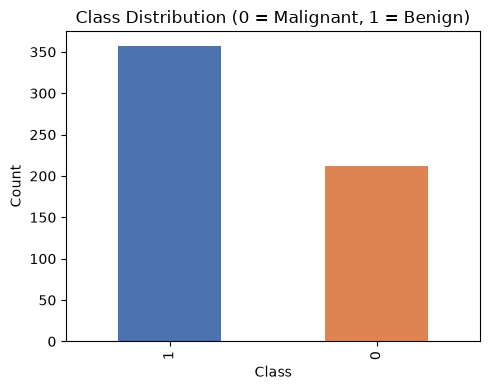

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
df["target"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Class Distribution (0 = Malignant, 1 = Benign)")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

**Plot explanation:**

This is a bar chart showing the **class distribution** in the dataset — i.e. how many samples belong to each class (0 or 1).

**Why does this plot matter?** Because it reveals whether the data is **balanced** or not. If one class is much larger than the other (imbalanced), a simple model can reach a high accuracy just by always predicting the majority class — which makes accuracy alone a misleading metric, and pushes us to also use metrics like F1-score (which we use below for the baseline).

## Step 3: Train the Baseline Model

Here we'll use **Logistic Regression** (a simple model from Week 3) as the baseline. Any neural network model we build later must beat this number.

In [4]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline_model = LogisticRegression(max_iter=5000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline F1-score: {baseline_f1:.4f}")

Baseline Accuracy: 0.9649
Baseline F1-score: 0.9726


**Code explanation (function by function):**

- `X = df.drop(columns=["target"])`: takes every column except the target — these are the features (inputs).
- `y = df["target"]`: the target column on its own — this is what we're trying to predict.
- `train_test_split(...)`: splits the data into two sets: **training** (80%) and **testing** (20%). `stratify=y` ensures the class ratio in the train and test sets matches the ratio in the original data (important when the data isn't perfectly balanced). `random_state=42` is just so the result is reproducible.
- `LogisticRegression(max_iter=5000)`: creates the logistic regression model; `max_iter` is the maximum number of iterations the algorithm runs to reach a solution (increase it if the model fails to converge).
- `.fit(X_train, y_train)`: this is where the **actual training** happens — the model learns the relationship between the features and the target from the training data.
- `.predict(X_test)`: uses the trained model to predict labels for the test data (which the model never saw during training).
- `accuracy_score` and `f1_score`: two metrics for evaluating prediction quality. Accuracy is the proportion of correct predictions; F1-score is the harmonic mean of precision and recall — more useful when classes aren't perfectly balanced.

📌 **This number (baseline_accuracy and baseline_f1) is what any later neural network must beat.**

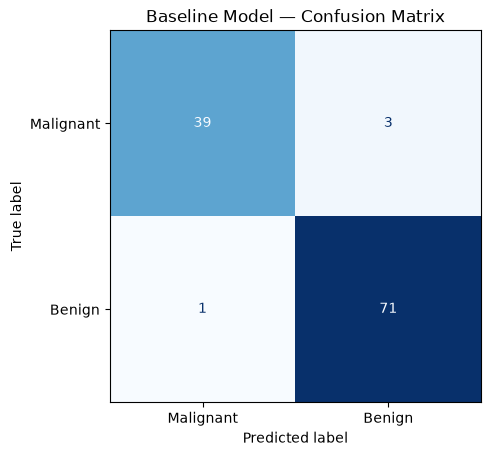

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Baseline Model — Confusion Matrix")
plt.tight_layout()
plt.show()

**Plot explanation (Confusion Matrix):**

This is a **confusion matrix** — it shows four numbers:

- **True Positives / True Negatives** (on the diagonal): the number of times the model predicted correctly.
- **False Positives / False Negatives** (off the diagonal): the number of times the model got it wrong — i.e. predicted one class when the true label was the other.

**Why does it matter?** Because it breaks down the *type* of error, not just "how many wrong overall." In a medical dataset like this one, for example, the difference between missing a malignant case (False Negative) and flagging a benign case as malignant (False Positive) is hugely important in practice — accuracy alone doesn't show that difference, but the confusion matrix makes it clear.

## 1.3 The Single Neuron — Built Manually, No Deep Learning Libraries

Now let's go back to the theory: a neuron isn't new math — it's exactly the **dot product** from Week 2, plus a bias, followed by an activation function.

```
z = (x1*w1) + (x2*w2) + ... + bias
output = activation(z)
```

We'll write it manually with numpy so we can see exactly what happens inside a neuron, with no "magic" hidden away.

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def neuron(inputs, weights, bias, activation=sigmoid):
    
    z = np.dot(inputs, weights) + bias  
    output = activation(z)
    return z, output


x = np.array([0.5, -1.2, 3.0])       
w = np.array([0.8, 0.3, -0.6])       
b = 0.1                              

z, output = neuron(x, w, b)
print(f"z (weighted sum + bias) = {z:.4f}")
print(f"output (after activation) = {output:.4f}")

z (weighted sum + bias) = -1.6600
output (after activation) = 0.1598


**Code explanation (function by function):**

- `sigmoid(z)`: a common activation function — it takes any number and returns a value between 0 and 1 (like a probability). This is what adds "non-linearity" to the neuron; without it, the neuron would just be a simple linear equation.
- `neuron(inputs, weights, bias, activation)`: this function represents one complete neuron:
  - `np.dot(inputs, weights)`: this computes the **weighted sum** — multiplying each input by its corresponding weight and summing them up (exactly the dot product you learned in Week 2).
  - `+ bias`: adds a constant number (bias) — this lets the neuron "shift" the result even if all the inputs were zero.
  - `activation(z)`: finally, we pass the result (z) through the activation function to get the neuron's final output.
- In the example: we have a neuron with three inputs (`x`), weights (`w`), and a bias (`b`) — the result `z` is the raw weighted sum + bias, and `output` is that same value after passing through the sigmoid and landing between 0 and 1.

## 1.4 Layers — From a Single Neuron to a Full Network

A neural network is just **several neurons organized into layers**, and each layer takes the outputs of the previous layer as its inputs.

| Layer | Role |
|---|---|
| Input layer | Receives the raw features (one node per feature) |
| Hidden layer(s) | Learn intermediate representations — more/wider layers = more capacity |
| Output layer | Produces the final prediction (its shape depends on the task) |

**"Deep" learning** simply means there's **more than one hidden layer**.

We'll build a small example: a network with an input layer (3 inputs) → hidden layer (4 neurons) → output layer (1 neuron), and run a manual forward pass.

In [ ]:
def dense_layer(inputs, weights_matrix, biases_vector, activation=sigmoid):
    """
    A full (dense) layer = several neurons computed at once.
    weights_matrix: each column holds the weights of one neuron in the layer.
    biases_vector: the bias for each neuron in the layer.
    """
    z = np.dot(inputs, weights_matrix) + biases_vector
    return activation(z)

np.random.seed(42)

x = np.array([0.5, -1.2, 3.0])

W_hidden = np.random.randn(3, 4) * 0.5     
b_hidden = np.zeros(4)

W_output = np.random.randn(4, 1) * 0.5     
b_output = np.zeros(1)

hidden_output = dense_layer(x, W_hidden, b_hidden)
final_output = dense_layer(hidden_output, W_output, b_output)

print("Hidden layer output (4 values):", hidden_output)
print("Final network output:", final_output)

Hidden layer output (4 values): [0.39185034 0.71499242 0.18531687 0.31468682]
Final network output: [0.29216664]


**Code explanation (function by function):**

- `dense_layer(inputs, weights_matrix, biases_vector, activation)`: same idea as the `neuron` function above, except instead of computing a single neuron it computes a **whole layer** at once — several neurons in one shot. Each column of `weights_matrix` is the weights of a different neuron in that layer, and each element of `biases_vector` is the bias of a different neuron.
- `W_hidden` with shape `(3, 4)`: means 3 inputs (matching the shape of `x`) and 4 neurons in the hidden layer — each hidden-layer neuron has 3 weights (one per input).
- `b_hidden`: the bias for each of the 4 neurons in the hidden layer.
- `W_output` with shape `(4, 1)`: the single output neuron takes the hidden layer's 4 outputs as its inputs, so it has 4 weights.
- **Forward pass:** this is the process where data flows from input → hidden → output, layer by layer:
  1. `hidden_output = dense_layer(x, W_hidden, b_hidden)`: the input layer's output (i.e. `x` itself) passes through the hidden layer, giving us 4 values (one per hidden-layer neuron).
  2. `final_output = dense_layer(hidden_output, W_output, b_output)`: the hidden layer's output (the 4 values) passes through the output layer, giving us the network's final value.

📌 **The key takeaway:** the weights (`W_hidden`, `W_output`) and biases here are **completely random** (not yet trained) — exactly like a brand-new, untrained neural network. Days 2 and 3 will cover how these weights get adjusted gradually during training to become accurate.

## Step 4 & 5: Document the Baseline & Commit

**Step 4 — Git:** (run from the terminal, not inside the notebook)

```bash
git checkout -b feature/sprint1-baseline
git add .
git commit -m "Sprint 1: baseline model + EDA"
git push origin feature/sprint1-baseline
# Then open a draft Pull Request on GitHub
```

**Step 5 — Formally record the baseline score:**

> ✅ **Baseline Accuracy = 96.49%**
> ✅ **Baseline F1-score = 97.26%**
>
> **Any neural network model we build in the coming days must score higher than these numbers, or there's no justification for using it instead of the simple model.**
